# Semester Project
## Detroit 311 Service Request Analysis

**Student Name:** Zejun Li

**U-M Unique Name:** zejunli

**Research Question:** 
Do neighborhoods in Detroit differ in 311 request volume and request type, and are those differences associated with neighborhood socioeconomic characteristics?

## 1. Setup and Data Loading

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.spatial.distance import pdist, squareform

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

### Load data 

In [8]:
# Load data from CSV (make sure the file is in the same folder as this notebook)
df = pd.read_csv('improve_detroit_6989920847396108344.csv', low_memory=False)

# Convert date column for filtering and analysis
df['Date Created'] = pd.to_datetime(df['Date Created'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

## 2. Data Description

In [ ]:
# Basic structure
df.info()

# Check missing values
df.isna().sum()

# Summary statistics for key categorical variables
df['ZIP Code'].value_counts()
df['Request Type Title'].value_counts().head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700928 entries, 0 to 700927
Data columns (total 27 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Issue ID            700928 non-null  int64         
 1   Address             700928 non-null  object        
 2   Request Type Title  700928 non-null  object        
 3   Status              700928 non-null  object        
 4   Report Method       700928 non-null  object        
 5   Priority Code       700928 non-null  int64         
 6   Date Created        700928 non-null  datetime64[ns]
 7   Date Acknowledged   652810 non-null  object        
 8   Date Updated        700928 non-null  object        
 9   Date Closed         675735 non-null  object        
 10  Date Reopened       7584 non-null    object        
 11  Days to Close       675735 non-null  float64       
 12  Hours to Close      675735 non-null  float64       
 13  Issue URL           700928 no

Request Type Title
DPW - Debris Removal - DPW USE ONLY         97444
DPW - Other environmental - DPW USE ONLY    68116
Illegal Dump Sites                          66074
Curbside Solid Waste Issue                  55998
Abandoned Vehicle - On Street               53145
Tree Issue                                  28916
Potholes                                    27232
Curbside - DPW ONLY                         26799
Rodent Extermination                        25869
Investigate Water Main Break                19995
Name: count, dtype: int64

## 3. Data Cleaning
To keep this assignment manageable, I picked five zip codes that are socioeconomically diverse to make the analysis interesting: 
- 48202, New Center/Midtown: Higher income, institutional
- 48205, East Detroit: Lower income, high blight
- 48214, East Riverfront: Mixed, gentrifying
- 48221, Bagley/Sherwood Forest: Middle income
- 48228, West Detroit: Lower income, working class

In [12]:
# Keep five socioeconomically diverse Detroit ZIP codes
detroit_zips = ['48202', '48205', '48214', '48221', '48228']

# Convert ZIP Code 
df['ZIP Code'] = df['ZIP Code'].astype(str).str.replace('.0', '', regex=False).str.strip().str.zfill(5)

# Filter to Detroit ZIPs and 2023, drop missing essentials
original_len = len(df)

df_clean = df[df['ZIP Code'].isin(detroit_zips)].copy()
df_clean = df_clean.dropna(subset=['Date Created', 'ZIP Code', 'Request Type Title'])
df_clean = df_clean[
    (df_clean['Date Created'] >= '2023-01-01') &
    (df_clean['Date Created'] < '2024-01-01')
]

cleaned_len = len(df_clean)
removed_len = original_len - cleaned_len
removed_pct = (removed_len / original_len) * 100

print(f"Original dataset: {original_len:,} records")
print(f"Cleaned dataset: {cleaned_len:,} records")
print(f"Removed: {removed_len:,} records ({removed_pct:.1f}%)")

Original dataset: 700,928 records
Cleaned dataset: 13,573 records
Removed: 687,355 records (98.1%)


## 4.Exploratory Data Analysis

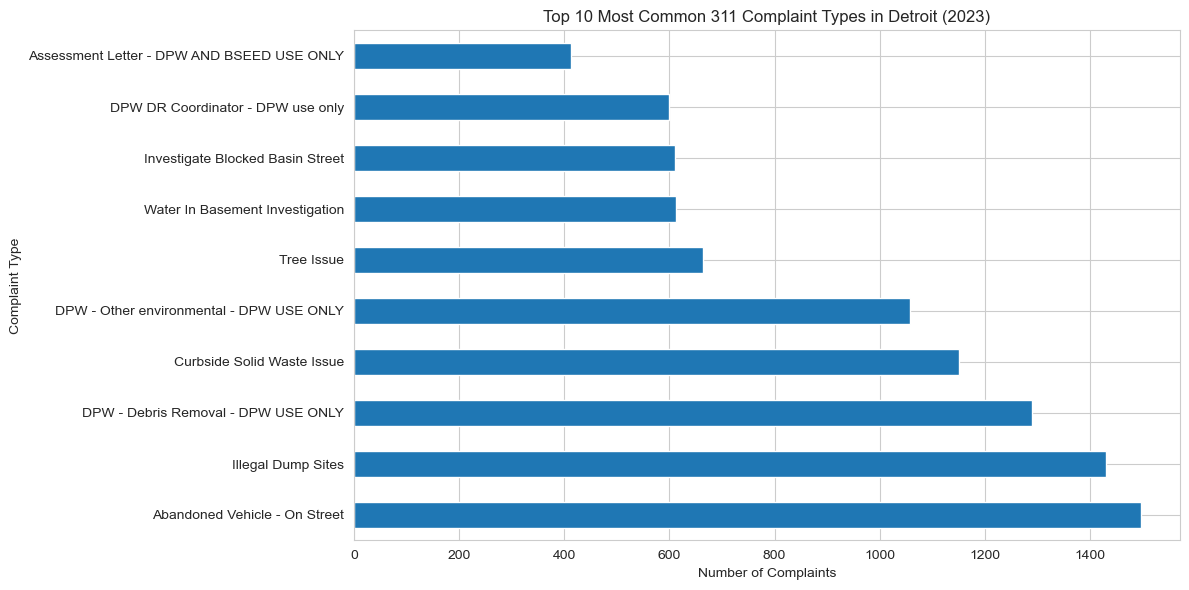

In [13]:
# Most common complaint types across all ZIP codes
complaint_counts = df_clean['Request Type Title'].value_counts().head(10)

plt.figure(figsize=(12, 6))
complaint_counts.plot(kind='barh')
plt.xlabel('Number of Complaints')
plt.ylabel('Complaint Type')
plt.title('Top 10 Most Common 311 Complaint Types in Detroit (2023)')
plt.tight_layout()
plt.show()

## 5.Research Question Analysis

To examine whether neighborhoods exhibit distinct 311 service request signatures, I compare the relative frequency of complaint types across boroughs. Using proportions rather than raw counts allows for meaningful comparisons that are not driven solely by population size or reporting volume.

In [16]:
# Count complaints by ZIP code and complaint type
zip_complaints = (
    df_clean
    .groupby(['ZIP Code', 'Request Type Title'])
    .size()
    .reset_index(name='count')
)

# Convert counts to proportions within each ZIP code
zip_complaints['proportion'] = (
    zip_complaints['count'] /
    zip_complaints.groupby('ZIP Code')['count'].transform('sum')
)

zip_complaints.head()

,ZIP Code,Request Type Title,count,proportion
0,48202,Abandoned Vehicle - On Street,116,0.090062
1,48202,Abandoned Vehicles – On private property,14,0.010870
2,48202,Alley Debris Pick Up – DGC Only,31,0.024068
3,48202,Alley Debris – GSD ONLY,3,0.002329
4,48202,Alley Grading - DPW Use Only,5,0.003882


In [21]:
# Top complaint types per ZIP
for zip in detroit_zips:
    print(f"\n--- {zip} ---")
    print(zip_complaints[zip_complaints['ZIP Code'] == zip].nlargest(5, 'proportion')[['Request Type Title', 'proportion']])

# Most/least similar ZIP pairs
print("\n--- Distance Matrix ---")
print(distance_matrix)


--- 48202 ---
                     Request Type Title  proportion
19                   Illegal Dump Sites    0.092391
0         Abandoned Vehicle - On Street    0.090062
22     Investigate Blocked Basin Street    0.061335
12  DPW - Debris Removal - DPW USE ONLY    0.060559
11           Curbside Solid Waste Issue    0.047360

--- 48205 ---
                      Request Type Title  proportion
63   DPW - Debris Removal - DPW USE ONLY    0.109708
70                    Illegal Dump Sites    0.108305
52         Abandoned Vehicle - On Street    0.083053
65     DPW DR Coordinator - DPW use only    0.078283
101      Water In Basement Investigation    0.071549

--- 48214 ---
                           Request Type Title  proportion
102             Abandoned Vehicle - On Street    0.124931
121                        Illegal Dump Sites    0.095212
114  DPW - Other environmental - DPW USE ONLY    0.078701
113       DPW - Debris Removal - DPW USE ONLY    0.065493
148                                

## Key Visualizations

Create at least 3 polished visualizations that answer your research question

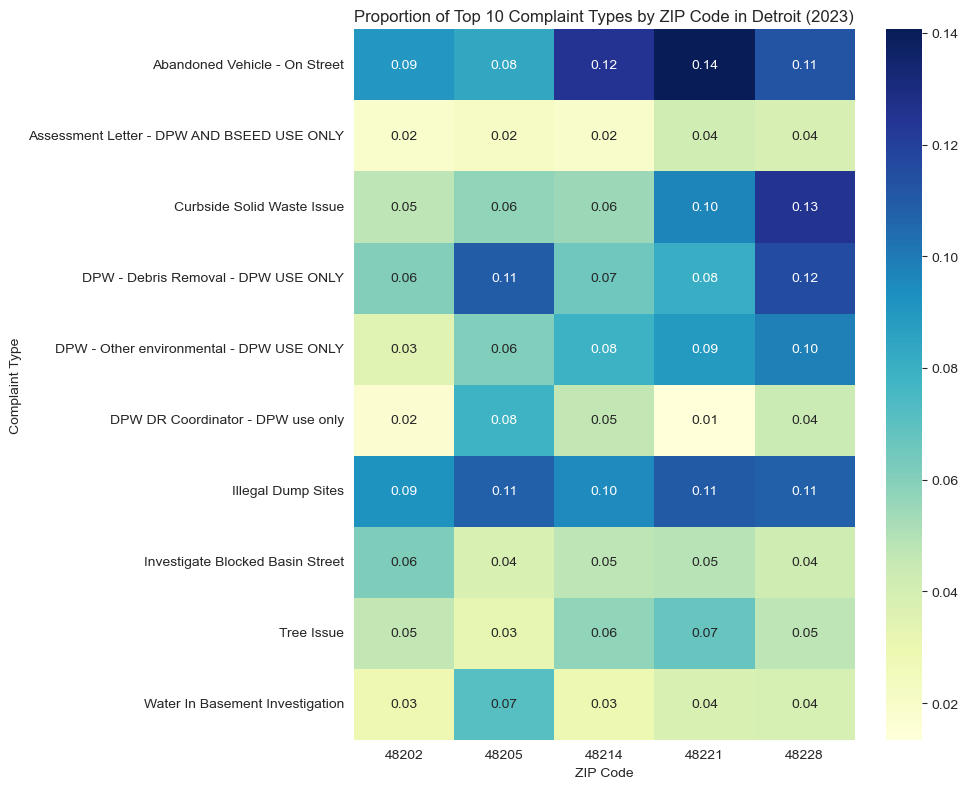

In [17]:
# Visualization 1 - ZIP code complaint proportion

top10_types = df_clean['Request Type Title'].value_counts().head(10).index

heatmap_data = (
    zip_complaints[zip_complaints['Request Type Title'].isin(top10_types)]
    .pivot(index='Request Type Title', columns='ZIP Code', values='proportion')
    .fillna(0)
)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Proportion of Top 10 Complaint Types by ZIP Code in Detroit (2023)")
plt.xlabel("ZIP Code")
plt.ylabel("Complaint Type")
plt.tight_layout()
plt.show()

Interpretation of Visualization 1: This heatmap shows the relative frequency of the ten most common complaint types across the five Detroit ZIP codes. Clear differences emerge across neighborhoods. Abandoned vehicles and illegal dump sites appear as dominant complaint types across all five ZIPs, reflecting citywide blight challenges, but their relative share varies notably by neighborhood. 48205 shows a particularly high concentration of debris removal requests, while 48214 stands out for its higher proportion of abandoned vehicle complaints relative to other ZIPs. These differences suggest that while Detroit's 311 complaints share a common blight-related character, neighborhoods still exhibit distinct service request compositions.

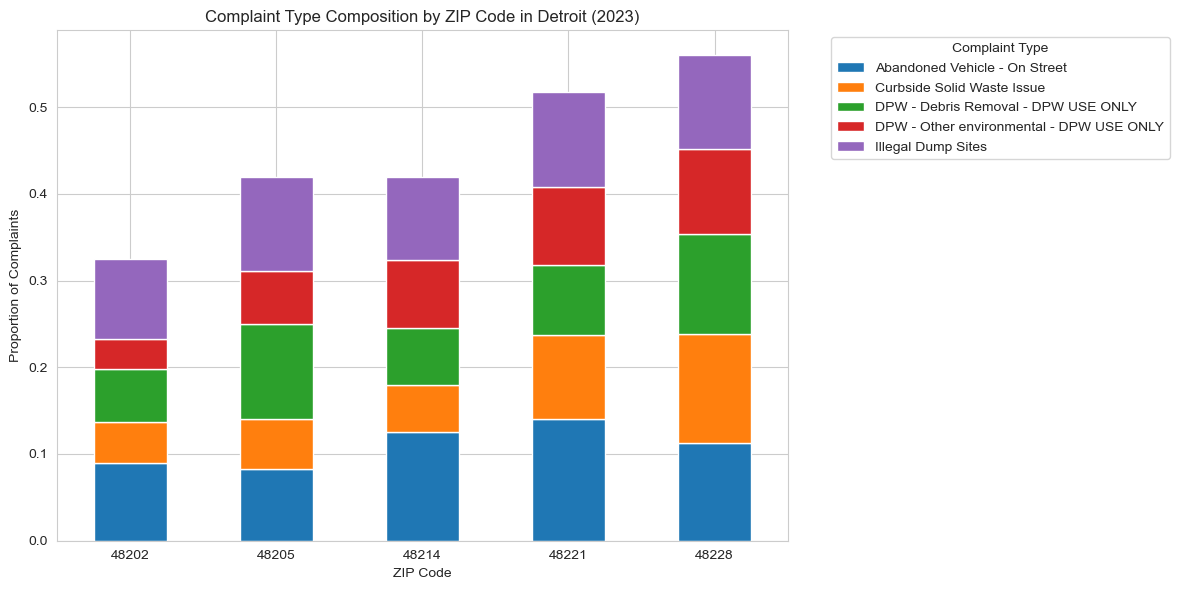

In [18]:
# Visualization 2 - ZIP code complaint composition

# Keep top 5 complaint types overall
top5_types = (
    df_clean['Request Type Title']
    .value_counts()
    .head(5)
    .index
)

stacked_data = (
    zip_complaints[zip_complaints['Request Type Title'].isin(top5_types)]
    .pivot(index='ZIP Code', columns='Request Type Title', values='proportion')
    .fillna(0)
)

stacked_data.plot(kind='bar', stacked=True)
plt.title("Complaint Type Composition by ZIP Code in Detroit (2023)")
plt.ylabel("Proportion of Complaints")
plt.xlabel("ZIP Code")
plt.xticks(rotation=0)
plt.legend(title="Complaint Type", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Interpretation of Visualization 2: This stacked bar chart illustrates the composition of the five most common complaint types within each ZIP code. 48205 is heavily dominated by debris removal and illegal dumping complaints, consistent with its status as a lower-income area with significant infrastructure challenges. 48214 shows the highest share of abandoned vehicle complaints among the five ZIPs. 48221 and 48228 show relatively more balanced distributions across complaint types. These patterns suggest that complaint composition reflects local neighborhood conditions, with lower-income ZIPs skewing more heavily toward blight and debris-related issues.

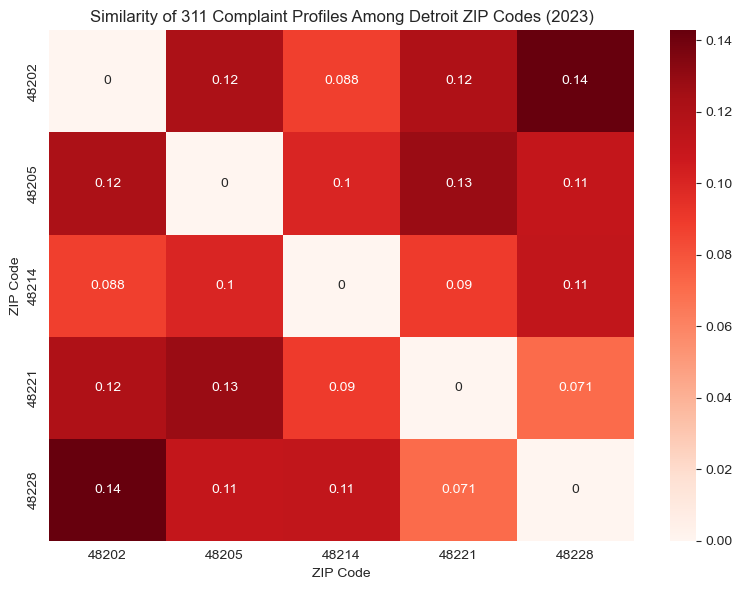

In [19]:
# Visualization 3 - Complaint profile similarity

# Create ZIP-by-complaint proportion matrix
profile_matrix = zip_complaints.pivot(
    index='ZIP Code',
    columns='Request Type Title',
    values='proportion'
).fillna(0)

# Compute distance between ZIP codes
distance_matrix = pd.DataFrame(
    squareform(pdist(profile_matrix, metric='euclidean')),
    index=profile_matrix.index,
    columns=profile_matrix.index
)

plt.figure(figsize=(8, 6))
sns.heatmap(distance_matrix, annot=True, cmap='Reds')
plt.title("Similarity of 311 Complaint Profiles Among Detroit ZIP Codes (2023)")
plt.tight_layout()
plt.show()

Interpretation of Visualization 3: The similarity heatmap shows that 48221 and 48228 have the most similar complaint profiles, with a distance score of 0.071 — the lowest in the matrix — suggesting these two west-side ZIP codes share comparable neighborhood service request patterns. In contrast, 48202 and 48228 are the most dissimilar pair, with a distance of 0.143, reflecting meaningful differences in complaint composition between Midtown and west Detroit. 48205 and 48214 fall in between, each showing moderately distinct profiles. Overall, the matrix highlights that even within a single city, ZIP codes exhibit meaningfully different 311 signatures that likely reflect underlying differences in housing conditions, infrastructure, and neighborhood context.